# 4.2 Práctica 2. Cobertura indoor de campus u hospital

**Objetivo:** Adaptar el ejercicio de penetración indoor a un edificio real donde interesa que funcionen voz, mensajería y acceso a plataformas digitales.

**Escenario:** Se estudia un edificio de varias plantas con fachada, tabiquería y un semisótano técnico. El alumno debe determinar en qué puntos basta la cobertura exterior y en cuáles haría falta DAS, repetidor o small cell.

**Conceptos que refuerza:** Pérdida outdoor-to-indoor, penetración por fachada, paredes y forjados, interpolación, presupuesto de enlace.

**Herramientas open source:** Python, Jupyter y QGIS.

**Datos de partida recomendados:** Portadora LTE 1800 o UMTS 2100 de respaldo. Antena exterior a 20-25 m. Pérdidas tipo: fachada 12-18 dB, pared interior 3-5 dB, forjado 12-18 dB.

## Tareas del alumno:
- Definir tres puntos de usuario: entrada del edificio, aula de segunda planta y semisótano o archivo.
- Calcular pérdida total incluyendo propagación exterior y penetración interior.
- Comprobar si el nivel recibido supera el umbral de servicio para voz y datos básicos.
- Proponer una solución de mejora si no se alcanza el objetivo.

## Entregables:
- Tabla con pérdidas por tramo.
- Croquis del edificio con puntos de medida.
- Recomendación final: cobertura macro suficiente o necesidad de refuerzo indoor.

## Extensión opcional:
Comparar el efecto de mover la portadora a 700/800 MHz o a 2600 MHz.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
%pip install numpy pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 85.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 84.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 85.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 108.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 78.2 MB/s  0:00:00
   ━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/9 [numpy]]  WARNING: The scripts f2py and numpy-config are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━ 4/9 [fonttools]  WARNING: The scripts fonttools, pyftmerge, pyftsubset and ttx are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress 

In [5]:
# Parámetros del sistema
freq = 1800  # MHz
tx_power = 40  # dBm
tx_gain = 15  # dBi
rx_gain = 0  # dBi
cable_loss = 2  # dB
distance = 0.1  # km (100 m)
antenna_height = 25  # m
building_height = 0  # assume ground level

# Pérdidas típicas
loss_facade = 15  # dB
loss_wall = 4  # dB
loss_floor = 15  # dB

# Umbrales de servicio
threshold_voice = -95  # dBm (RSCP para UMTS, similar para LTE)
threshold_data = -95  # dBm

## 1. Definir puntos de usuario en el edificio

Seleccionamos tres ubicaciones:
- **Punto 1: Entrada del edificio** - Nivel planta baja, cerca de la fachada.
- **Punto 2: Aula de segunda planta** - Segunda planta, interior.
- **Punto 3: Semisótano o archivo** - Semisótano, interior.

In [7]:
# Definir puntos de usuario y sus pérdidas de penetración
points = {
    'Entrada': {'facade': 1, 'walls': 0, 'floors': 0},
    'Aula segunda planta': {'facade': 1, 'walls': 2, 'floors': 2},
    'Semisótano': {'facade': 1, 'walls': 1, 'floors': 1}  # Asumiendo semisótano requiere penetrar un forjado hacia abajo
}

## 2. Calcular pérdidas de propagación exterior

Usamos el modelo de espacio libre para estimar la pérdida desde la antena exterior hasta la fachada del edificio.

In [6]:
# Calcular pérdida de espacio libre
fspl = 20 * np.log10(distance) + 20 * np.log10(freq) + 32.44
shadowing = 10  # dB, estimado
outdoor_loss = fspl + shadowing

print(f"Pérdida de propagación exterior: {outdoor_loss:.2f} dB")

Pérdida de propagación exterior: 87.55 dB


## 3. Calcular pérdidas de penetración por fachada, paredes y forjados

Aplicamos los valores típicos de pérdida para cada elemento según el recorrido hasta cada punto de usuario.

In [8]:
# Calcular pérdidas totales
results = {}
for point, losses in points.items():
    penetration_loss = (losses['facade'] * loss_facade + 
                        losses['walls'] * loss_wall + 
                        losses['floors'] * loss_floor)
    total_loss = outdoor_loss + penetration_loss
    received_power = tx_power + tx_gain - cable_loss - total_loss + rx_gain
    results[point] = {
        'outdoor_loss': outdoor_loss,
        'facade_loss': losses['facade'] * loss_facade,
        'wall_loss': losses['walls'] * loss_wall,
        'floor_loss': losses['floors'] * loss_floor,
        'total_loss': total_loss,
        'received_power': received_power
    }

# Mostrar resultados
df = pd.DataFrame.from_dict(results, orient='index')
print(df)

                     outdoor_loss  facade_loss  wall_loss  floor_loss  \
Entrada                  87.54545           15          0           0   
Aula segunda planta      87.54545           15          8          30   
Semisótano               87.54545           15          4          15   

                     total_loss  received_power  
Entrada               102.54545       -49.54545  
Aula segunda planta   140.54545       -87.54545  
Semisótano            121.54545       -68.54545  


## 4. Sumar pérdidas totales por tramo

La tabla anterior muestra las pérdidas acumuladas para cada tramo y cada punto de usuario.

## 5. Verificar nivel recibido frente a umbral de servicio

Calculamos el nivel recibido en cada punto y lo comparamos con los umbrales de servicio para voz y datos básicos (-95 dBm).

In [9]:
# Verificar umbrales
for point, data in results.items():
    power = data['received_power']
    sufficient = power >= threshold_voice
    print(f"{point}: Potencia recibida = {power:.2f} dBm - {'Suficiente' if sufficient else 'Insuficiente'}")

Entrada: Potencia recibida = -49.55 dBm - Suficiente
Aula segunda planta: Potencia recibida = -87.55 dBm - Suficiente
Semisótano: Potencia recibida = -68.55 dBm - Suficiente


## 6. Proponer solución de mejora si es necesario

Si el nivel recibido no es suficiente, sugerimos la instalación de DAS, repetidor o small cell en los puntos críticos.

In [10]:
# Recomendaciones
recommendations = {}
for point, data in results.items():
    if data['received_power'] < threshold_voice:
        if point == 'Entrada':
            rec = "Instalar un repetidor cerca de la entrada."
        elif point == 'Aula segunda planta':
            rec = "Implementar DAS en la segunda planta."
        else:
            rec = "Usar small cell en el semisótano."
        recommendations[point] = rec
    else:
        recommendations[point] = "Cobertura macro suficiente."

for point, rec in recommendations.items():
    print(f"{point}: {rec}")

Entrada: Cobertura macro suficiente.
Aula segunda planta: Cobertura macro suficiente.
Semisótano: Cobertura macro suficiente.


## 7. Visualizar croquis del edificio y puntos de medida

Utilizamos matplotlib para mostrar un croquis simple del edificio con los puntos de usuario marcados.

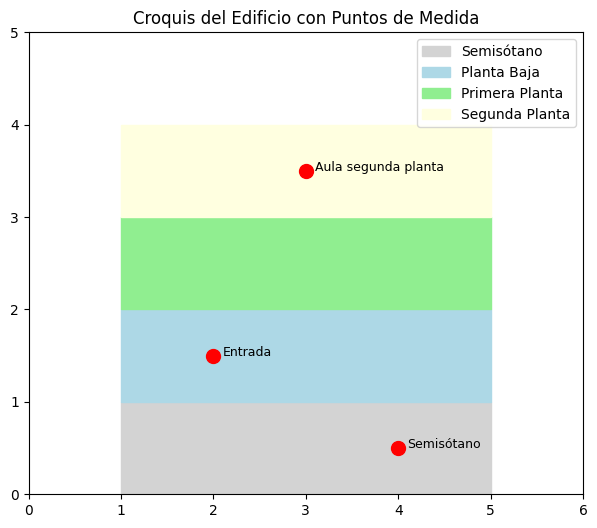

In [11]:
# Croquis simple del edificio
fig, ax = plt.subplots(figsize=(8, 6))

# Dibujar edificio: semisótano, planta baja, primera, segunda
ax.add_patch(plt.Rectangle((1, 0), 4, 1, fill=True, color='lightgray', label='Semisótano'))
ax.add_patch(plt.Rectangle((1, 1), 4, 1, fill=True, color='lightblue', label='Planta Baja'))
ax.add_patch(plt.Rectangle((1, 2), 4, 1, fill=True, color='lightgreen', label='Primera Planta'))
ax.add_patch(plt.Rectangle((1, 3), 4, 1, fill=True, color='lightyellow', label='Segunda Planta'))

# Puntos de medida
points_coords = {
    'Entrada': (2, 1.5),
    'Aula segunda planta': (3, 3.5),
    'Semisótano': (4, 0.5)
}

for point, (x, y) in points_coords.items():
    ax.plot(x, y, 'ro', markersize=10)
    ax.text(x+0.1, y, point, fontsize=9)

ax.set_xlim(0, 6)
ax.set_ylim(0, 5)
ax.set_aspect('equal')
ax.set_title('Croquis del Edificio con Puntos de Medida')
ax.legend()
plt.show()

## 8. Comparar efecto de diferentes bandas de frecuencia (opcional)

Repetimos los cálculos para portadoras en 700/800 MHz y 2600 MHz, y analizamos cómo cambia la cobertura.

In [12]:
# Comparar frecuencias
frequencies = [700, 800, 1800, 2600]
comparison = {}

for f in frequencies:
    fspl_f = 20 * np.log10(distance) + 20 * np.log10(f) + 32.44
    outdoor_loss_f = fspl_f + shadowing
    for point, losses in points.items():
        penetration_loss = (losses['facade'] * loss_facade + 
                            losses['walls'] * loss_wall + 
                            losses['floors'] * loss_floor)
        total_loss_f = outdoor_loss_f + penetration_loss
        received_power_f = tx_power + tx_gain - cable_loss - total_loss_f + rx_gain
        if point not in comparison:
            comparison[point] = {}
        comparison[point][f] = received_power_f

df_comp = pd.DataFrame(comparison)
print("Potencia recibida (dBm) para diferentes frecuencias:")
print(df_comp)

Potencia recibida (dBm) para diferentes frecuencias:
        Entrada  Aula segunda planta  Semisótano
700  -41.341961           -79.341961  -60.341961
800  -42.501800           -80.501800  -61.501800
1800 -49.545450           -87.545450  -68.545450
2600 -52.739467           -90.739467  -71.739467
